In [1]:
!pwd

/home/greystone/locchuong/ocr-exp


In [241]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor
from circle_fit import taubinSVD

In [242]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

# 1.extract roi

In [243]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

In [244]:
def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

Text(0.5, 1.0, 'samples/pink/pink_99.jpg')

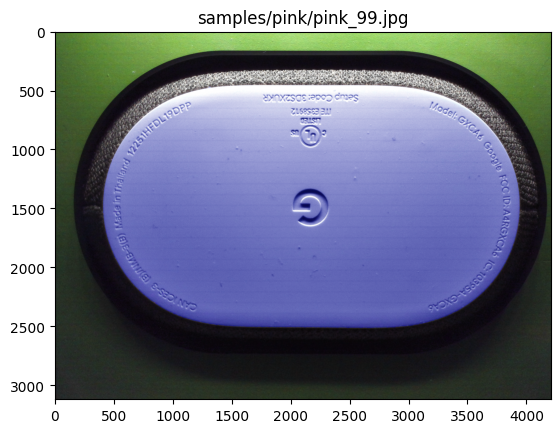

In [245]:
path = "samples/pink"
img_path = os.path.join(path,random.choice(os.listdir(path)))
img_org = cv2.imread(img_path) #Google Nest Audio.jpg
h,w,c=img_org.shape
if h>w:
    img_org = cv2.rotate(img_org,cv2.ROTATE_90_CLOCKWISE)
img = img_org.copy()
plt.imshow(img)
plt.title(img_path)

In [246]:
# extract mask
mask = extractor.get_mask(img)

In [247]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [248]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [249]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

(3104, 4192, 3)


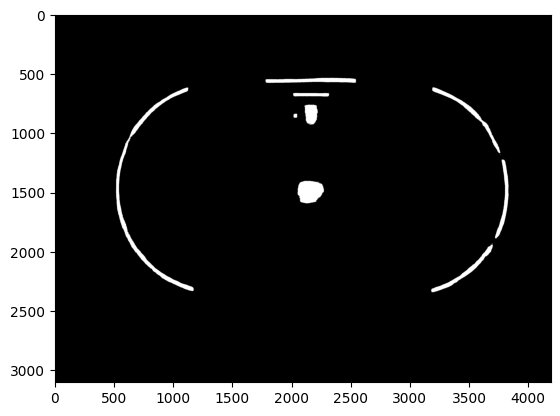

In [250]:
mask3 = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")])
print(mask3.shape)
plt.imshow(mask3)

boxs 8


Text(0.5, 1.0, 'greater then mean rotated rectangle')

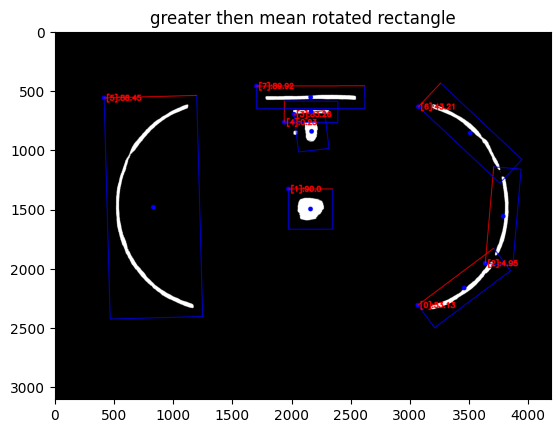

In [251]:
padding = 150
boxs = []
rects = []
angles = [] # degree
img = mask3.copy()
for i,cnt in enumerate(cnts):
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    # angle
    angle = rect[-1]
    angles.append(angle)
    # new rect add padding
    h = int(rect[1][0]+ padding)
    w = int(rect[1][1]+ padding)
    new_rect = (rect[0],(h,w),angle) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    boxs.append(box)
    # draw
    cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    cv2.circle(img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")

In [252]:
rois = []
masks = []

for i,t in enumerate(angles):
    # original input
    img = img_org.copy()
    img_mask = mask3.copy()
    rect = rects[i]
    box = boxs[i] # 4 pts form of rect
    rebox = box.reshape(-1,1,2)
    #rotate
    img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
    img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
    rebox = cv2.transform(rebox, M) # what you need
    # find new top left,bottom right
    dist = []
    for pt in rebox.reshape(-1,2):
        d = calc_dist(np.array([0,0]),pt)
        dist.append(d)
    top_left = rebox.reshape(-1,2)[np.argmin(dist)]
    bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
    w,h = bottom_right - top_left
    x,y = top_left
    out = img[y:y+h,x:x+w]
    out_m = img_mask[y:y+h,x:x+w]
    rois.append(out)
    masks.append(out_m)

In [253]:
for i,roi in enumerate(rois):
    h,w,c = roi.shape
    if h > w:
        roi = cv2.rotate(roi,cv2.ROTATE_90_CLOCKWISE)
        rois[i]=roi

In [254]:
for i,mask in enumerate(masks):
    h,w,c = mask.shape
    if h > w:
        mask = cv2.rotate(mask,cv2.ROTATE_90_CLOCKWISE)
        masks[i]=mask

<Figure size 640x480 with 0 Axes>

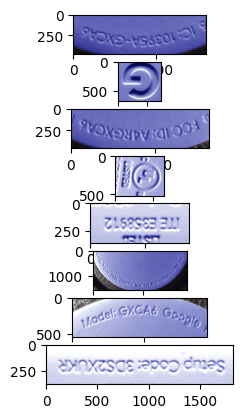

In [255]:
plt.figure()

fig,ax = plt.subplots(len(rois),1)
for i in range(len(rois)):
    ax[i].imshow(rois[i])

<Figure size 640x480 with 0 Axes>

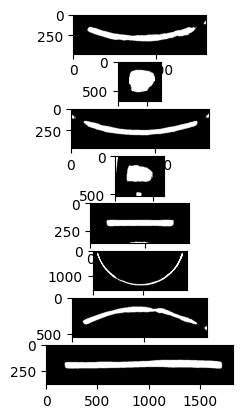

In [256]:
plt.figure()

fig,ax = plt.subplots(len(masks),1)
for i in range(len(masks)):
    ax[i].imshow(masks[i])

# 2.fit-in circle

(546, 1884)


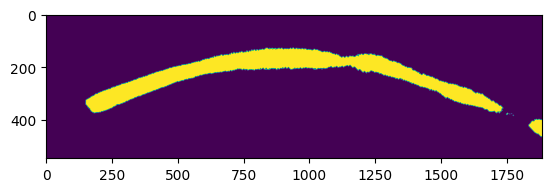

In [257]:
idx=-2
mask = masks[idx]
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
h,w = mask.shape
print(mask.shape)
plt.imshow(mask)

In [258]:
curve = []
for i in range(w):
    v_line = mask[:,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        curve.append((pos[0][0][1],i))

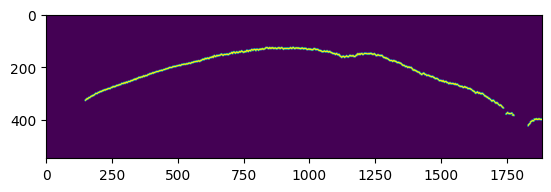

In [259]:
blank = np.zeros_like(mask)
for point in curve:
    cv2.circle(blank,(point[1], point[0]), 3, (255,255,255), -1)
plt.imshow(blank)

In [260]:
xc, yc, r, sigma = taubinSVD(curve[20:-20])
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

xc=1756, yc=924, r=1621, sigma=6.695747596132898


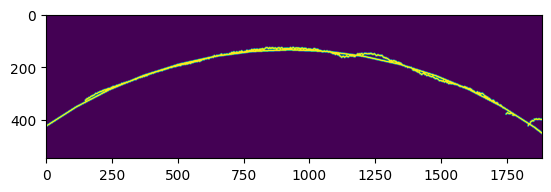

In [261]:
cv2.circle(blank, (int(yc),int(xc)), int(r), (255), 6)
plt.imshow(blank)

In [262]:
if xc<0:
    masks[idx] = cv2.rotate(masks[idx],cv2.ROTATE_180)
    rois[idx] = cv2.rotate(rois[idx],cv2.ROTATE_180)
    plt.imshow(masks[idx])

# 3.wrap roi

In [263]:
r_offset = 400

In [264]:
r = int(r) +r_offset

In [265]:
blank = np.zeros((r*2,r*2,3))
mask = np.zeros((r*2,r*2,3))
blank = blank.astype(np.uint8)
print(blank.shape)
# plt.imshow(blank)

(4042, 4042, 3)


In [266]:
x = int(r - w/2)
y = 0

In [267]:
x2 = x+w
y2 = h

In [268]:
blank[y:y2,x:x2].shape

(546, 1884, 3)

Text(0.5, 1.0, 'color')

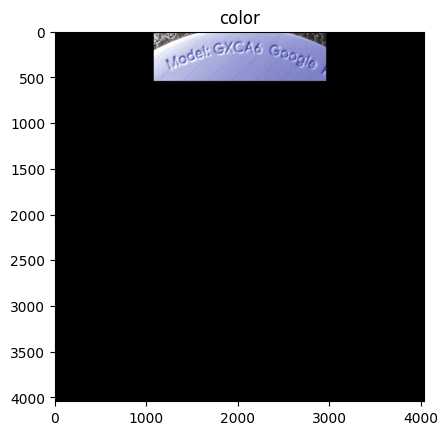

In [269]:
blank[y:y2,x:x2]= rois[idx]
plt.imshow(blank)
plt.title("color")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'mask')

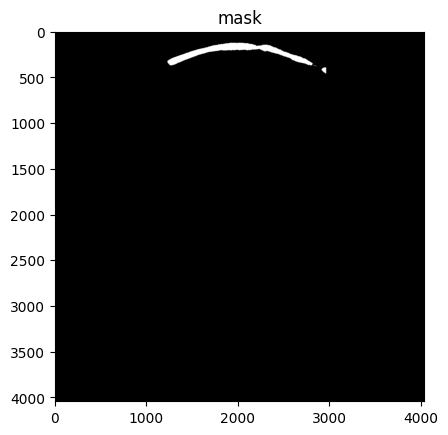

In [270]:
mask[y:y2,x:x2]= masks[idx]
plt.imshow(mask)
plt.title("mask")

In [271]:
padding = 50
v_offset = -20

Text(0.5, 1.0, 'color')

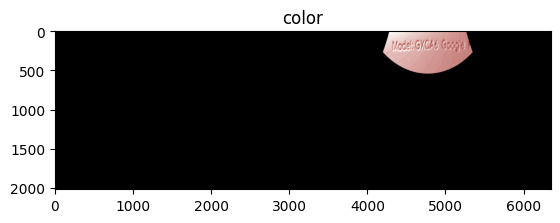

In [272]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_img = cv2.warpPolar(blank,(0,0),(r,r),r,flags) # r,r*2
out = polar_img.transpose(1,0,2)[::-1]
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title('color')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'mask')

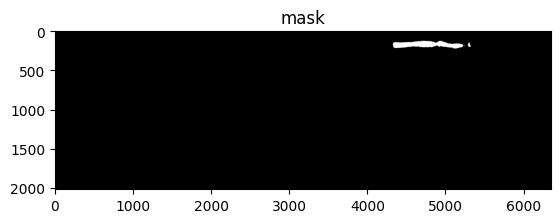

In [273]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_mask = cv2.warpPolar(mask,(0,0),(r,r),r,flags) # w,h
out_m = polar_mask.transpose(1,0,2)[::-1]
plt.imshow(out_m)
plt.title('mask')

In [274]:
# convert to np.uint8
out_m = out_m.astype(np.uint8)
print(f"max value: {out_m.max()}")
print(f"min value: {out_m.min()}")

max value: 255
min value: 0


In [275]:
gray = cv2.cvtColor(out_m, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(len(contours))

210


In [276]:
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)
    
cnt_max = contours[np.argmax(areas)]

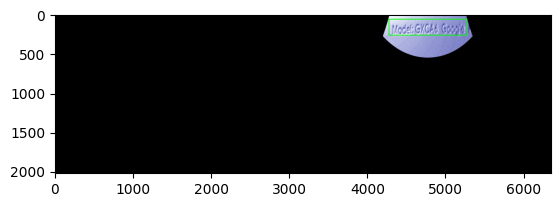

In [277]:
img = out.copy()
xr,yr,w,h = cv2.boundingRect(cnt_max)
cv2.rectangle(img,(xr-padding,yr-padding+v_offset),(xr+w+padding,yr+h+padding+v_offset),(0,255,0),10)
plt.imshow(img)

In [278]:
x0=xr-padding
y0=yr-padding+v_offset
x1=xr+w+padding
y1=yr+h+padding+v_offset
print(f"x0={x0},y0={y0},x1={x1},y1={y1}")

x0=4266,y0=53,x1=5264,y1=257


(2021, 6349, 3)


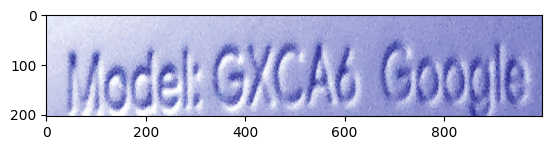

In [279]:
out2 = out[y0:y1,x0:x1]
print(out.shape)
plt.imshow(out2)

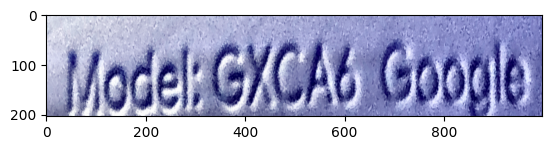

In [280]:
lab= cv2.cvtColor(out2, cv2.COLOR_BGR2LAB)
l_channel, a, b = cv2.split(lab)

# Applying CLAHE to L-channel
# feel free to try different values for the limit and grid size:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l_channel)

# merge the CLAHE enhanced L-channel with the a and b channel
limg = cv2.merge((cl,a,b))

# Converting image from LAB Color model to BGR color spcae
out2 = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
plt.imshow(out2)

In [281]:
cv2.imwrite("out.jpg",out2)

True

# 4.Text recognition

[2023/01/03 17:41:13] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='/home/greystone/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='paddle_ocr/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='total

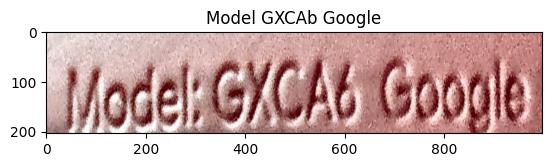

In [282]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(det_model_dir='paddle_ocr/ch_PP-OCRv3_det_infer',
                rec_model_dir='paddle_ocr/ch_PP-OCRv3_rec_infer',
                use_angle_cls=True,use_gpu=False)

img_path = 'out.jpg'
result = ocr.ocr(img_path, det=False, rec=True, cls=True)
for line in result:
    print(line)

img = cv2.imread(img_path)
plt.imshow(img[...,::-1])
plt.title(result[0][0][0])
plt.savefig('rec.jpg')
plt.show()

In [197]:
#!git clone https://github.com/PaddlePaddle/PaddleOCR.git

# %cd PaddleOCR

# !ls

#!pip install -r requirements.txt

#!wget -P ./pretrain_models/ https://paddleocr.bj.bcebos.com/rec_r45_abinet_train.tar

# %cd pretrain_models

# !tar -xf rec_r45_abinet_train.tar && rm -rf rec_r45_abinet_train.tar

# %cd ..

# Predict English results

# !python3 tools/infer_rec.py -c configs/rec/rec_r45_abinet.yml\
#                             -o Global.pretrained_model=./pretrain_models/rec_r45_abinet_train/best_accuracy\
#                             Global.infer_img=out.jpg\
#                             Global.use_gpu=False

# references

[train paddle](https://medium.com/@prishanga1/paddleocr-scene-text-recognition-in-the-wild-with-custom-dataset-59fd5f5cf6c3)

[PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR/tree/release/2.6/doc/doc_en)

[RapidOCR](https://github.com/RapidAI/RapidOCR)

[PaddleOCR with OpenVINO](https://docs.openvino.ai/latest/notebooks/405-paddle-ocr-webcam-with-output.html)

[openvino-paddlepaddle-demo](https://github.com/raymondlo84/openvino-paddlepaddle-demo)

[Interactive Tutorials (Python) openvino](https://docs.openvino.ai/latest/tutorials.html#doxid-tutorials)

[openvino-paddle](https://docs.openvino.ai/latest/openvino_docs_MO_DG_prepare_model_convert_model_Convert_Model_From_Paddle.html#)

[mmocr-guide](https://analyticsindiamag.com/a-guide-to-text-detection-and-recognition-using-mmocr/)

[mmocr](https://github.com/open-mmlab/mmocr)

[opencv-text-recognition](https://docs.opencv.org/4.x/d4/d43/tutorial_dnn_text_spotting.html)

[ocr-opencv-dnn](https://github.com/hpc203/ocr-opencv-dnn)

[deep-text-recognition-benchmark](https://github.com/clovaai/deep-text-recognition-benchmark)


[AdelaiDet](https://github.com/aim-uofa/AdelaiDet)


[adaptive-bezier-curve-network](https://www.kaggle.com/code/ipythonx/scene-text-spotting-adaptive-bezier-curve-network)